In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Handling the Missing Data

In [19]:
import pandas as pd
import seaborn as sns
from sklearn.utils import resample

In [4]:
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset('titanic')
df1=df.copy()

In [5]:
# Check missing values
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
# Delete the rows or data point to handle missing values
df.dropna().shape

(182, 15)

In [7]:
## Column wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


Mean Value Imputation

In [9]:
# Impute missing values in 'Age' using the mean
mean_age = df1['age'].mean()
df1['age_mean'] = df1['age'].fillna(mean_age)

# Display the first few rows
print(df1[['age', 'age_mean']].head())

    age  age_mean
0  22.0      22.0
1  38.0      38.0
2  26.0      26.0
3  35.0      35.0
4  35.0      35.0


Median Value Imputation

In [10]:
df['age_median']=df['age'].fillna(df['age'].median())

Mode Value Imputation

In [12]:
# Impute missing values in 'Embarked' using the mode
mode_embarked = df['embarked'].mode()[0]
df['embarked_mode'] = df['embarked'].fillna(mode_embarked)

Random Sampling Imputation

In [13]:
# Function to perform random sampling imputation
def random_imputation(column):
    missing = column.isnull()
    num_missing = missing.sum()
    sampled_values = column.dropna().sample(num_missing, random_state=42)
    sampled_values.index = column[missing].index
    column[missing] = sampled_values
    return column

# Impute missing values in 'Age' using random sampling
df['age_random'] = random_imputation(df['age'])

# Display the first few rows
print(df[['age', 'age_random']].head())

    age  age_random
0  22.0        22.0
1  38.0        38.0
2  26.0        26.0
3  35.0        35.0
4  35.0        35.0


/tmp/ipykernel_9091/3564733790.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column[missing] = sampled_values


Handling the Imbalanced Dataset

Methods to Handle Imbalanced Datasets

1.Upsampling and Downsampling

In [15]:
# Creating an imbalanced dataset
df_imbalanced = df[df['survived'].isin([0, 1])]
print("Original Target Distribution:")
print(df_imbalanced['survived'].value_counts())

Original Target Distribution:
survived
0    549
1    342
Name: count, dtype: int64


In [20]:
# Separate majority and minority classes
majority = df_imbalanced[df_imbalanced['survived'] == 0]
minority = df_imbalanced[df_imbalanced['survived'] == 1]

# Upsample minority class
minority_upsampled = resample(minority,
                              replace=True,
                              n_samples=len(majority),
                              random_state=42)

# Combine majority and upsampled minority
df_upsampled = pd.concat([majority, minority_upsampled])

print("\nAfter Upsampling:")
print(df_upsampled['survived'].value_counts())


After Upsampling:
survived
0    549
1    549
Name: count, dtype: int64


In [22]:
# Downsample majority class
majority_downsampled = resample(majority,
                                replace=False,
                                n_samples=len(minority),
                                random_state=42)

# Combine minority and downsampled majority
df_downsampled = pd.concat([majority_downsampled, minority])

print("\nAfter Downsampling:")
print(df_downsampled['survived'].value_counts())


After Downsampling:
survived
0    342
1    342
Name: count, dtype: int64


SMOTE (Synthetic Minority Oversampling Technique)

In [23]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

X, y = make_classification(n_classes=2, class_sep=2,
weights=[0.1, 0.9], n_informative=3, n_redundant=1, flip_y=0,
n_features=20, n_clusters_per_class=1, n_samples=1000, random_state=10)
print('Original dataset shape %s' % Counter(y))

Original dataset shape Counter({np.int64(1): 900, np.int64(0): 100})


In [24]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 900, np.int64(1): 900})


Data Encoding

One-Hot Encoding

In [25]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Step 1: Create a simple dataframe
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'green', 'red', 'blue']
})

# Step 2: Create an instance of OneHotEncoder
encoder = OneHotEncoder()

# Step 3: Perform fit and transform
# Transform the 'color' column into a one-hot encoded array
encoded_array = encoder.fit_transform(df[['color']]).toarray()

# Step 4: Convert the encoded array into a DataFrame for better readability
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['color']))

# Combine the original and encoded data
final_df = pd.concat([df, encoded_df], axis=1)

# Display the final DataFrame
print(final_df)

   color  color_blue  color_green  color_red
0    red         0.0          0.0        1.0
1   blue         1.0          0.0        0.0
2  green         0.0          1.0        0.0
3  green         0.0          1.0        0.0
4    red         0.0          0.0        1.0
5   blue         1.0          0.0        0.0


Label Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Perform fit and transform
# Transform the 'color' column into numerical labels
encoded_labels = label_encoder.fit_transform(df['color'])

# Add the encoded labels as a new column in the dataframe
df['color_encoded'] = encoded_labels

# Display the final DataFrame
print(df)

   color  color_encoded
0    red              2
1   blue              0
2  green              1
3  green              1
4    red              2
5   blue              0


Ordinal Encoding

In [27]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Step 1: Create a simple dataframe
df = pd.DataFrame({
    'education_level': ['high school', 'college', 'graduate', 'post-graduate', 'high school', 'graduate']
})

# Step 2: Define the order of categories
education_order = ['high school', 'college', 'graduate', 'post-graduate']

# Step 3: Create an instance of OrdinalEncoder with the defined category order
ordinal_encoder = OrdinalEncoder(categories=[education_order])

# Step 4: Perform fit and transform
# Transform the 'education_level' column into ordinal values
df['education_encoded'] = ordinal_encoder.fit_transform(df[['education_level']])

# Display the final DataFrame
print(df)

  education_level  education_encoded
0     high school                0.0
1         college                1.0
2        graduate                2.0
3   post-graduate                3.0
4     high school                0.0
5        graduate                2.0


Target Guided Ordinal Encoding

In [29]:
import pandas as pd

# Step 1: Create a sample dataset
data = {
    'City': ['New York', 'London', 'Paris', 'New York', 'London', 'Paris', 'New York'],
    'Sales': [200, 150, 180, 220, 170, 190, 210]
}
df = pd.DataFrame(data)

# Step 2: Calculate the mean Sales for each City
city_sales_mean = df.groupby('City')['Sales'].mean()

# Step 3: Map the mean Sales values to the City column
df['City_encoded'] = df['City'].map(city_sales_mean)

# Display the final DataFrame
print(df)

       City  Sales  City_encoded
0  New York    200         210.0
1    London    150         160.0
2     Paris    180         185.0
3  New York    220         210.0
4    London    170         160.0
5     Paris    190         185.0
6  New York    210         210.0


Discretization

Types of Discretization

1.Equal-Width Binning:

In [30]:
import pandas as pd
import numpy as np

# Step 1: Create a sample dataset
data = {'Age': [5, 12, 17, 24, 30, 45, 60, 75]}
df = pd.DataFrame(data)

# Step 2: Perform equal-width binning
df['Age_binned'] = pd.cut(df['Age'], bins=3, labels=['Young', 'Adult', 'Senior'])

# Display the final DataFrame
print(df)

   Age Age_binned
0    5      Young
1   12      Young
2   17      Young
3   24      Young
4   30      Adult
5   45      Adult
6   60     Senior
7   75     Senior


2.Equal-Frequency Binning

In [31]:
# Perform equal-frequency binning
df['Equal_Frequency_Binning'] = pd.qcut(df['Age'], q=3, labels=['Young', 'Adult', 'Senior'])

# Display the results
print(df)

   Age Age_binned Equal_Frequency_Binning
0    5      Young                   Young
1   12      Young                   Young
2   17      Young                   Young
3   24      Young                   Adult
4   30      Adult                   Adult
5   45      Adult                  Senior
6   60     Senior                  Senior
7   75     Senior                  Senior


3.Custom Binning

In [32]:
# Define custom bin edges and labels
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Young Adult', 'Middle Aged', 'Senior']

# Perform custom binning
df['Custom_Binning'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Display the results
print(df)

   Age Age_binned Equal_Frequency_Binning Custom_Binning
0    5      Young                   Young          Child
1   12      Young                   Young          Child
2   17      Young                   Young          Child
3   24      Young                   Adult    Young Adult
4   30      Adult                   Adult    Young Adult
5   45      Adult                  Senior    Middle Aged
6   60     Senior                  Senior    Middle Aged
7   75     Senior                  Senior         Senior


Handling Outliers

In [33]:
import numpy as np
import pandas as pd

# Step 1: Create a dataset
data = [10, 12, 15, 18, 20, 22, 24, 35, 50, 100]  # Example data with potential outliers
df = pd.DataFrame(data, columns=['Value'])

# Step 2: Calculate 5-number summary
minimum = np.min(data)
maximum = np.max(data)
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

# Step 3: Determine outlier thresholds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Step 4: Identify outliers
outliers = df[(df['Value'] < lower_bound) | (df['Value'] > upper_bound)]

# Print the results
print(f"5-Number Summary:")
print(f"Minimum: {minimum}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Maximum: {maximum}")
print(f"IQR: {iqr}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Outliers:\n{outliers}")

5-Number Summary:
Minimum: 10
Q1: 15.75
Median: 21.0
Q3: 32.25
Maximum: 100
IQR: 16.5
Lower Bound: -9.0
Upper Bound: 57.0
Outliers:
   Value
9    100


2. Boxplot Visualization

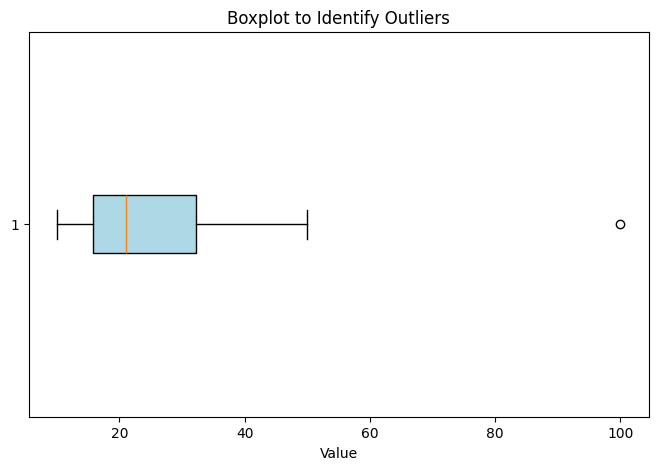

In [34]:
import matplotlib.pyplot as plt

# Step 5: Create a boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(data, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'))
plt.title("Boxplot to Identify Outliers")
plt.xlabel("Value")
plt.show()